# Parte 4: Galeria de falhas e horizonte de memória

O modelo final é o da Trilha A (RNN como modelo de movimento): um `MotionModel` GRU pequeno (H = 64, uma camada, entrada só geométrica), com um estado recorrente por track e associação por IoU entre a caixa prevista e as detecções. A regra e os hiperparâmetros de associação são os mesmos do baseline da Parte 1 (Hungarian, IoU ≥ 0,3, `max_age = 20`). A fonte de detecções é congelada: SDP público, score ≥ 0,9. Tudo é avaliado nas sequências de validação (MOT17-09 e MOT17-10), que o modelo nunca viu.

O notebook tem quatro partes:

1. O modelo final, treinado (ou carregado do checkpoint) e comparado com o baseline.
2. O horizonte de memória, medido de duas formas. A analítica é ‖∂L_t/∂h_{t−k}‖ em função de k, para o GRU e para uma RNN simples com o mesmo orçamento de parâmetros. A empírica é quantos quadros a identidade sobrevive a um buraco, comparada com a distribuição de duração das oclusões do GT.
3. Uma galeria de falhas: três trechos em que o modelo erra, com figura e diagnóstico numérico.
4. A correção sugerida pelo diagnóstico, com antes e depois em 3 seeds e um controle. O modelo corrigido é o modelo final usado na Parte 5 (`reports/5_stress_test.ipynb`).

Código: `src/nn/train.py` (treino e checkpoint), `src/analysis/memory.py`, figuras em `src/plot/plot.py`.

Para rodar localmente, use `reports/` como diretório de trabalho e instale as dependências com `pip install -r requirements.txt`. No Colab o notebook roda isolado, sem git e sem downloads. A primeira célula monta o Google Drive, lê as anotações de `Meu Drive > PA2 > data` (a pasta `MOT17Labels` ou o zip) e procura o código do projeto em `Meu Drive > PA2` ou num `image-detection.zip` enviado para `/content`. Os quadros (`MOT17Det`, 1,9 GB) são opcionais. Com `USE_FRAMES = True` e a pasta em `PA2 > data`, eles aparecem no fundo das figuras. Sem eles, a galeria usa fundo cinza. Com os checkpoints em `results/`, o notebook roda em cerca de 1 min em CPU. Sem eles, o treino leva de 20 a 40 s por modelo.

In [ ]:
import os, sys, glob, zipfile

IN_COLAB = "google.colab" in sys.modules
DRIVE_PA2 = "/content/drive/MyDrive/PA2"
DRIVE_DATA = os.path.join(DRIVE_PA2, "data")
USE_FRAMES = False


def find_project(base):
    hits = glob.glob(os.path.join(base, "**", "src", "dataset", "mot17.py"), recursive=True)
    return os.path.dirname(os.path.dirname(os.path.dirname(hits[0]))) if hits else None


def find_labels(base):
    hits = glob.glob(os.path.join(base, "**", "train", "MOT17-02-FRCNN", "seqinfo.ini"), recursive=True)
    return os.path.dirname(os.path.dirname(os.path.dirname(hits[0]))) if hits else None


if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    # codigo
    project = find_project(DRIVE_PA2)
    if project is None and os.path.exists("/content/image-detection.zip"):
        with zipfile.ZipFile("/content/image-detection.zip") as z:
            z.extractall("/content/image-detection")
        project = find_project("/content/image-detection")
    if project is None:
        raise FileNotFoundError(f"codigo do projeto (src/) nao encontrado em {DRIVE_PA2} nem em /content/image-detection.zip")
    os.chdir(os.path.join(project, "reports"))

    # dados: o codigo espera <DATA_ROOT>/MOT17Labels/train/...
    DATA_ROOT = "/content/data"
    os.makedirs(DATA_ROOT, exist_ok=True)
    target = os.path.join(DATA_ROOT, "MOT17Labels")
    if not os.path.exists(target):
        labels = find_labels(DRIVE_DATA)
        if labels is not None:
            os.symlink(labels, target)
        else:
            zips = glob.glob(os.path.join(DRIVE_DATA, "**", "MOT17Labels*.zip"), recursive=True)
            if not zips:
                raise FileNotFoundError(f"MOT17Labels (pasta ou zip) nao encontrado em {DRIVE_DATA}")
            with zipfile.ZipFile(zips[0]) as z:
                z.extractall(os.path.join(DATA_ROOT, "_labels"))
            os.symlink(find_labels(os.path.join(DATA_ROOT, "_labels")), target)
    if USE_FRAMES:
        frames_dir = glob.glob(os.path.join(DRIVE_DATA, "**", "MOT17Det"), recursive=True)
        if frames_dir and not os.path.exists(os.path.join(DATA_ROOT, "MOT17Det")):
            os.symlink(frames_dir[0], os.path.join(DATA_ROOT, "MOT17Det"))
else:
    if os.path.basename(os.getcwd()) != "reports" and os.path.isdir("reports"):
        os.chdir("reports")
    DATA_ROOT = os.path.join(os.path.abspath(".."), "data")

ROOT = os.path.abspath("..")
sys.path.append(ROOT)
print("projeto:", ROOT, "| dados:", DATA_ROOT, "| MOT17Labels:", os.path.isdir(os.path.join(DATA_ROOT, "MOT17Labels")))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
projeto: /content/drive/MyDrive/PA2 | dados: /content/data | MOT17Labels: True


In [ ]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.dataset.mot17 import load_sequences, SPLIT, evaluate_sequence, occlusion_durations
from src.nn.models import cell_parameter_count, hidden_size_for_budget, count_parameters
from src.nn.train import load_or_train, DEFAULT_CONFIG, CORRECTED_CONFIG
from src.analysis.memory import TRACKER, gradient_curve, effective_horizon, free_running_iou, run_tracker, empirical_horizon, crossing, keep_rate_between, pick_failures, diagnose

from src.plot.plot import plot_gradient_curves, plot_memory_horizon, plot_failure_case


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cpu"

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
SEEDS = (0, 1, 2)

pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)

seqs = load_sequences(root=DATA_ROOT)
TRAIN = [seqs[n] for n in SPLIT["train"]]
VAL = [seqs[n] for n in SPLIT["val"]]
for s in VAL:
    print(s, "| quadros em disco:", s.has_images)

MOT17Sequence(MOT17-09, 525 quadros @ 30 fps, 1920x1080, 26 ids) | quadros em disco: False
MOT17Sequence(MOT17-10, 654 quadros @ 30 fps, 1920x1080, 57 ids) | quadros em disco: False


## 1. O modelo final

`MotionModel` (`src/nn/models.py`) com célula GRU escrita do zero, H = 64. A cada quadro ele recebe `[caixa_t, caixa_t − caixa_{t−1}, observado]` (cx, cy, w, h normalizados pela imagem) e prevê o resíduo da caixa do quadro seguinte. Sob oclusão (track sem par), a entrada é a própria previsão com `observado = 0`, e o estado roda para frente sem observação.

Treino (`src/nn/train.py`): trajetórias do GT das 5 sequências de treino, janelas de T = 16 (igual à janela do BPTT), oclusão simulada de 2 a 8 quadros em metade das janelas, smooth-L1, Adam, 15 épocas e clipping 1,0. A entrada não tem confiança nem Δt. No treino a confiança seria a visibilidade do GT e na inferência seria o score do detector, então deixá-la de fora elimina uma fonte de desvio de distribuição. São 3 seeds, e o checkpoint de cada uma fica em `results/`.

In [ ]:
def gru(seed, tag="", **cfg):
    path = os.path.join(RESULTS_DIR, f"4_motion_gru{tag}_s{seed}.pt")
    return load_or_train(path, TRAIN, VAL, device=device, seed=seed, verbose=False, **cfg)[0]


final = {s: gru(s) for s in SEEDS}
print("parametros:", count_parameters(final[0]))


def evaluate(model=None, seqs=VAL, **tracker_kwargs):
    rows = {}
    for s in seqs:
        pred, _ = run_tracker(s, model, **tracker_kwargs)
        r = evaluate_sequence(pred, s, detection_map=False)
        rows[s.name] = {k: r[k] for k in ("IDF1", "IDSW", "FRAG", "IDSW_per_gt_id", "n_pred_ids", "n_gt_ids", "id_ratio")}
    return pd.DataFrame(rows).T


def over_seeds(models, **tracker_kwargs):
    tables = [evaluate(m, **tracker_kwargs) for m in models.values()]
    mean = sum(tables) / len(tables)
    mean["IDF1_std"] = pd.concat([t["IDF1"] for t in tables], axis=1).std(axis=1)
    return mean


base = evaluate(None)
final_eval = over_seeds(final)
comparison = pd.concat({"baseline Parte 1 (ultima caixa)": base, "GRU final (3 seeds)": final_eval})
print(comparison[["IDF1", "IDF1_std", "IDSW", "FRAG", "n_pred_ids", "n_gt_ids"]].to_string())

checkpoint carregado: results/4_motion_gru_s0.pt
checkpoint carregado: results/4_motion_gru_s1.pt
checkpoint carregado: results/4_motion_gru_s2.pt
parametros: 14468
                                           IDF1  IDF1_std     IDSW     FRAG  n_pred_ids  n_gt_ids
baseline Parte 1 (ultima caixa) MOT17-09  0.519       NaN   66.000  127.000      35.000      26.0
                                MOT17-10  0.501       NaN  327.000  460.000     185.000      57.0
GRU final (3 seeds)             MOT17-09  0.565     0.007   41.333  128.333      41.000      26.0
                                MOT17-10  0.530     0.016  231.333  454.667     169.333      57.0


## 2. Horizonte de memória efetivo

### 2.1 Analítico: ‖∂L_t / ∂h_{t−k}‖ em função de k

A perda é medida apenas no último passo de janelas de 48 quadros do GT de validação, e o backward lê o gradiente em cada estado anterior h_{t−k} (`src/nn/models.py::gradient_norm_through_time`). Comparamos o GRU final com uma RNN simples treinada com a mesma receita e com aproximadamente o mesmo número de parâmetros na célula (`hidden_size_for_budget`, que resulta em H = 114). O horizonte analítico é o primeiro k em que a norma cai abaixo de 5 % da norma em k = 0.

O gráfico da direita mostra o mesmo horizonte pela saída. O estado vê 8 caixas verdadeiras e depois roda k quadros só com as próprias previsões, como numa oclusão. O IoU médio entre a caixa prevista e a verdadeira mostra por quanto tempo a posição sobrevive, e o limiar de associação (0,3) marca o ponto em que a track deixa de conseguir casar com a pessoa que volta.

checkpoint carregado: results/4_motion_rnn_s0.pt
orcamento da celula: 14208 parametros -> RNN simples com H = 114


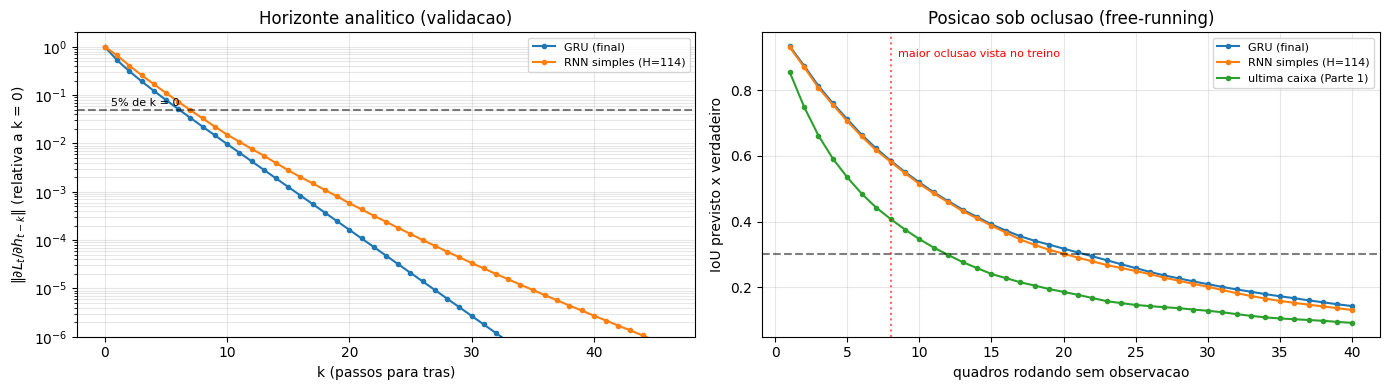

GRU (final)              horizonte (5%) =  7 passos | norma em k=4: 0.123, k=8: 0.0223, queda de 45x em 8 passos
RNN simples (H=114)      horizonte (5%) =  7 passos | norma em k=4: 0.169, k=8: 0.0330, queda de 30x em 8 passos
quadros de free-running ate o IoU cair abaixo do limiar de associacao: {'GRU (final)': 22, 'RNN simples (H=114)': 21, 'ultima caixa (Parte 1)': 12}


In [6]:
budget = cell_parameter_count("gru", final[0].input_size, 64)
h_rnn = hidden_size_for_budget("rnn", final[0].input_size, budget)
rnn = load_or_train(os.path.join(RESULTS_DIR, "4_motion_rnn_s0.pt"), TRAIN, VAL, device=device,
                    cell="rnn", hidden_size=h_rnn, verbose=False)[0]
print(f"orcamento da celula: {budget} parametros -> RNN simples com H = {h_rnn}")

curves = {"GRU (final)": gradient_curve(final[0], VAL), f"RNN simples (H={h_rnn})": gradient_curve(rnn, VAL)}
horizons = {k: effective_horizon(c) for k, c in curves.items()}

fr = {"GRU (final)": free_running_iou(final[0], VAL), f"RNN simples (H={h_rnn})": free_running_iou(rnn, VAL),
      "ultima caixa (Parte 1)": free_running_iou(None, VAL)}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_gradient_curves(curves, ax=axes[0], title="Horizonte analitico (validacao)")
for label, iou in fr.items():
    axes[1].plot(np.arange(1, len(iou) + 1), iou, marker=".", label=label)
axes[1].axhline(TRACKER["iou_threshold"], color="k", linestyle="--", alpha=0.5)
axes[1].axvline(DEFAULT_CONFIG["occlusion_len"][1], color="r", linestyle=":", alpha=0.6)
axes[1].text(DEFAULT_CONFIG["occlusion_len"][1] + 0.5, 0.9, "maior oclusao vista no treino", fontsize=8, color="r")
axes[1].set_xlabel("quadros rodando sem observacao"); axes[1].set_ylabel("IoU previsto x verdadeiro")
axes[1].set_title("Posicao sob oclusao (free-running)"); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

for k, c in curves.items():
    print(f"{k:24s} horizonte (5%) = {horizons[k]:2d} passos | norma em k=4: {c[4]:.3f}, k=8: {c[8]:.4f}, "
          f"queda de {1 / c[8]:.0f}x em 8 passos")
cross = {k: int(np.argmax(v < TRACKER['iou_threshold'])) + 1 for k, v in fr.items()}
print("quadros de free-running ate o IoU cair abaixo do limiar de associacao:", cross)

### 2.2 Empírico: quantos quadros a identidade sobrevive a um buraco

Para cada pessoa do GT, sempre que ela volta a ser casada depois de `gap` quadros presente no GT mas sem par previsto, registramos se o id é o mesmo de antes (`reacquisition_events`). A curva é a fração de recapturas que mantêm o id, por duração do buraco. As barras são a duração das oclusões do próprio GT, contando os trechos em que a visibilidade fica abaixo de 0,25 e a pessoa depois volta (`occlusion_durations`). O horizonte empírico é a duração de buraco em que a fração que mantém o id cruza 50 %, interpolada entre as faixas. Como esse número resume mal a cauda, reportamos também a taxa nos buracos de 5 a 19 quadros, em que a track ainda está viva mas já depende só da previsão.

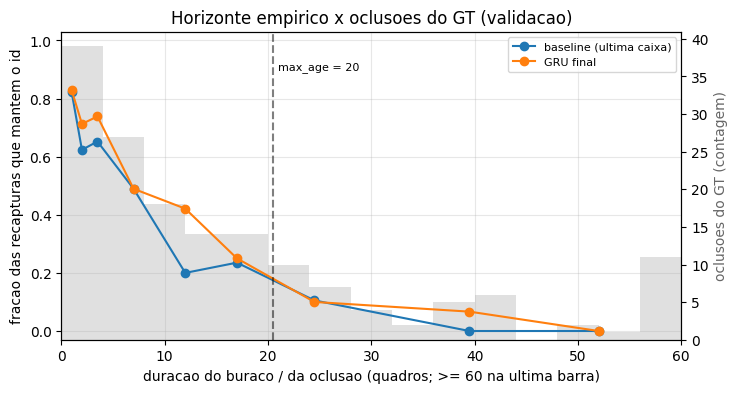

 gap_lo  gap_hi   n  keep_rate
      1     1.0 299      0.829
      2     2.0  87      0.713
      3     4.0  65      0.738
      5     9.0  47      0.489
     10    14.0  19      0.421
     15    19.0  16      0.250
     20    29.0  20      0.100
     30    49.0  15      0.067
     50     NaN  15      0.000

horizonte empirico (cruza 50%): baseline 6.8 quadros, GRU 6.9 quadros
baseline: mantem o id em 37% das 84 recapturas apos buracos de 5-19 quadros
GRU: mantem o id em 43% das 82 recapturas apos buracos de 5-19 quadros
oclusoes do GT: mediana 10 quadros, p75 23, p90 42; 62% delas sao mais longas que o horizonte empirico do GRU, 59% mais longas que o analitico


In [ ]:
def memory_profile(model, **tracker_kwargs):
    events, preds = {}, {}
    for s in VAL:
        preds[s.name] = run_tracker(s, model, **tracker_kwargs)
        events[s.name] = empirical_horizon(preds[s.name][0], s.gt)[0]
    all_events = [e for evs in events.values() for e in evs]
    return events, preds, all_events


occ = np.concatenate([occlusion_durations(s.gt) for s in VAL])
events_final, preds_final, all_final = memory_profile(final[0])
events_base, _, all_base = memory_profile(None)


def rates_and_horizon(all_events):
    from src.nn.metrics import keep_rate_by_gap
    rates = keep_rate_by_gap([e for e in all_events if e["gap"] > 0], bins=(1, 2, 3, 5, 10, 15, 20, 30, 50, 10**9))
    return rates, crossing(rates)


rates_final, hz_final = rates_and_horizon(all_final)
rates_base, hz_base = rates_and_horizon(all_base)

plot_memory_horizon({"baseline (ultima caixa)": rates_base, "GRU final": rates_final}, occ, max_age=TRACKER["max_age"], title="Horizonte empirico x oclusoes do GT (validacao)")
plt.show()

print(pd.DataFrame(rates_final).to_string(index=False))
print(f"\nhorizonte empirico (cruza 50%): baseline {hz_base:.1f} quadros, GRU {hz_final:.1f} quadros")
for name, evs in (("baseline", all_base), ("GRU", all_final)):
    rate, n = keep_rate_between(evs, 5, 20)
    print(f"{name}: mantem o id em {rate:.0%} das {n} recapturas apos buracos de 5-19 quadros")
print(f"oclusoes do GT: mediana {np.median(occ):.0f} quadros, p75 {np.percentile(occ, 75):.0f}, p90 {np.percentile(occ, 90):.0f}; "
      f"{np.mean(occ > hz_final):.0%} delas sao mais longas que o horizonte empirico do GRU, "
      f"{np.mean(occ > horizons['GRU (final)']):.0%} mais longas que o analitico")

## 3. Galeria de falhas

Três trechos do GRU final (seed 0) em que a identidade se perde, escolhidos automaticamente entre as recapturas com id trocado (`pick_failures`), um de cada tipo:

- Oclusão longa: o maior buraco que termina em id novo.
- Buraco médio: o maior buraco menor que `max_age`. Nele a track antiga ainda estava viva, então o erro é da previsão e não da regra de morte.
- Troca: duas pessoas trocam de id sem buraco.

Em cada figura, o GT da pessoa aparece em branco grosso (os demais GT em branco fino), as trajetórias previstas aparecem tracejadas e coloridas pelo id, e a caixa prevista pela recorrência para a track antiga aparece pontilhada. Essa caixa é o mapa intermediário. Embaixo está o centro x da pessoa no tempo, com o GT, as tracks antes e depois da troca e a previsão da recorrência durante o buraco.

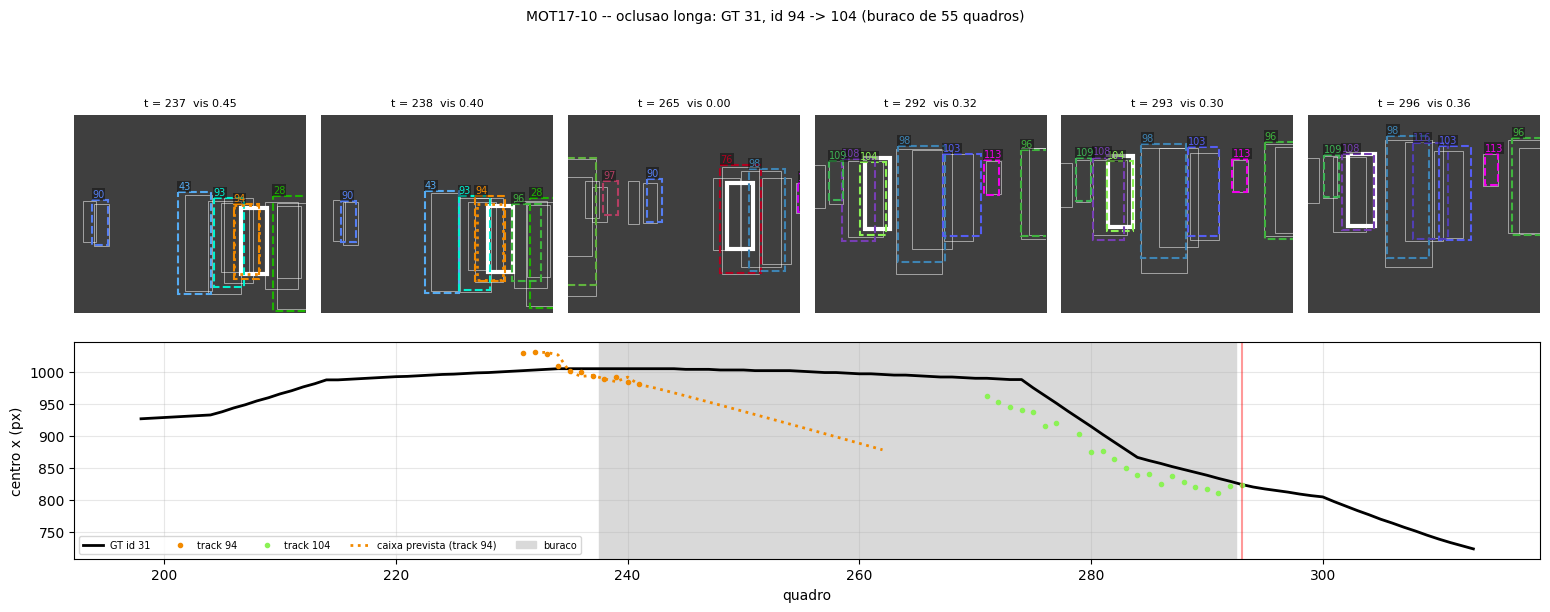

{
 "seq": "MOT17-10",
 "kind": "oclusao longa",
 "gt_id": 31,
 "frame": 293,
 "gap": 55,
 "min_vis": 0.0,
 "mean_vis": 0.06016470909090909,
 "id_before": 94,
 "id_after": 104,
 "track_alive": false,
 "died_by_max_age": true,
 "pred_iou": NaN,
 "visible_in_gap": 0,
 "other_gt": null
}


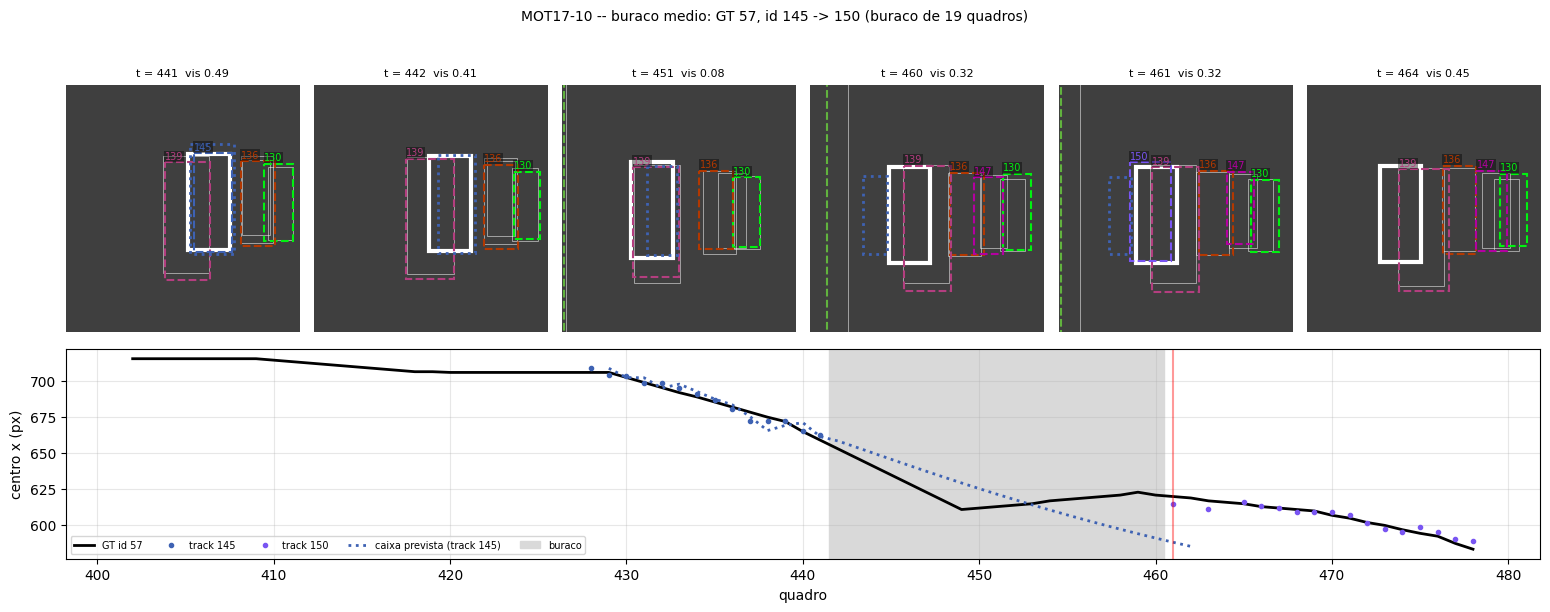

{
 "seq": "MOT17-10",
 "kind": "buraco medio",
 "gt_id": 57,
 "frame": 461,
 "gap": 19,
 "min_vis": 0.02381,
 "mean_vis": 0.16411026315789473,
 "id_before": 145,
 "id_after": 150,
 "track_alive": true,
 "died_by_max_age": false,
 "pred_iou": 0.0,
 "visible_in_gap": 0,
 "other_gt": null
}


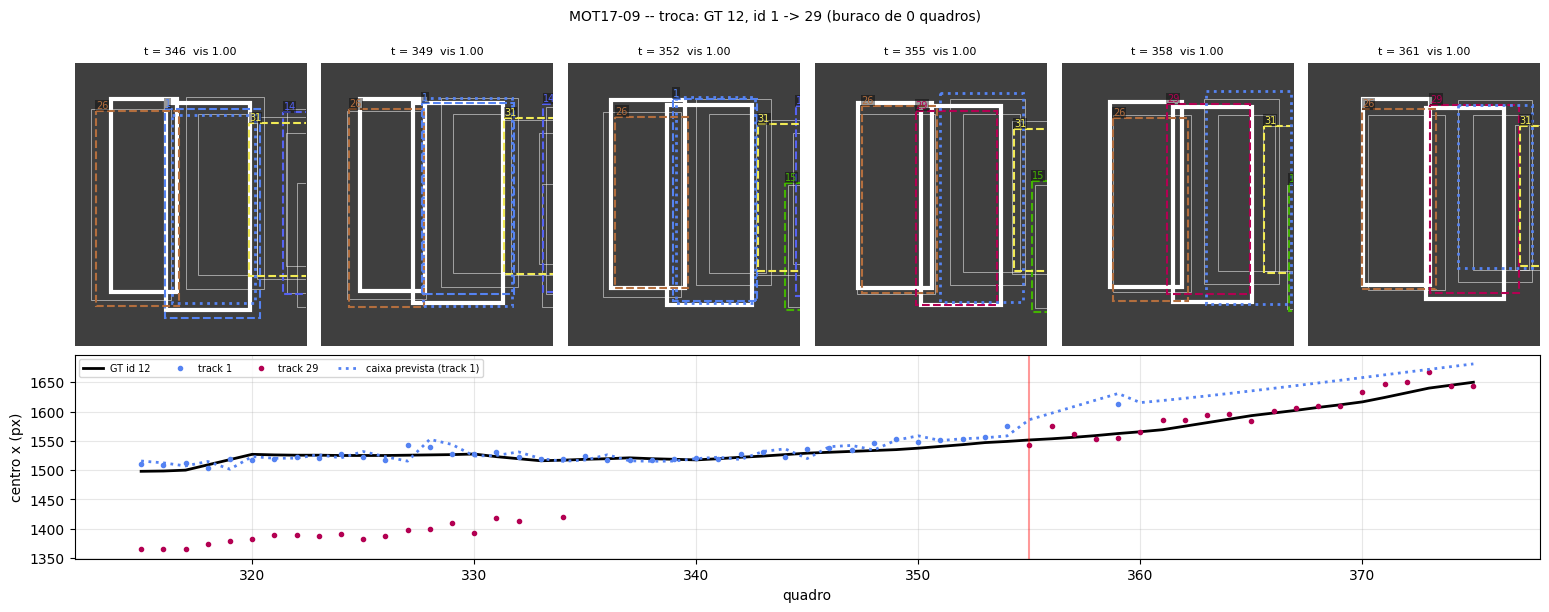

{
 "seq": "MOT17-09",
 "kind": "troca",
 "gt_id": 12,
 "frame": 355,
 "gap": 0,
 "min_vis": NaN,
 "mean_vis": NaN,
 "id_before": 1,
 "id_after": 29,
 "track_alive": true,
 "died_by_max_age": false,
 "pred_iou": 0.5556828528360549,
 "visible_in_gap": 0,
 "other_gt": 11
}


In [8]:
cases = pick_failures(events_final, seqs)
diagnoses = []

for case in cases:
    seq = seqs[case["seq"]]
    pred, predicted = preds_final[case["seq"]]
    d = diagnose(case, seq, pred, predicted)
    diagnoses.append(d)
    plot_failure_case(seq, case, pred, predicted)
    plt.show()
    print(json.dumps(d, indent=1))

### Diagnóstico dos três trechos

Oclusão longa (MOT17-10, GT 31, id 94 → 104). A pessoa fica 55 quadros sem par, com visibilidade média 0,06 e nenhum quadro com visibilidade ≥ 0,5. A track 94 morre por `max_age = 20` por volta do quadro 262. Enquanto ela estava viva, a caixa prevista seguiu para a esquerda (de x ≈ 1000 para x ≈ 880), mas a pessoa estava parada atrás do oclusor em x ≈ 1000. O GRU continuou a velocidade dos últimos quadros observados. O modelo foi treinado com janelas de T = 16 e oclusões de no máximo 8 quadros, então nunca recebeu supervisão para um buraco desse tamanho.

Buraco médio (MOT17-10, GT 57, id 145 → 150). A pessoa fica 19 quadros sem par, com visibilidade média 0,16, e a track 145 ainda está viva quando ela volta, no quadro 461. O GRU extrapolou em linha reta o movimento para a esquerda, mas a pessoa parou por volta do quadro 449 e voltou um pouco para a direita. No quadro 461 o centro previsto estava cerca de 30 px à esquerda do verdadeiro e o IoU entre as caixas era 0. Como a track estava viva, o erro aqui é da previsão e não da regra de morte.

Troca (MOT17-09, GT 12, id 1 → 29, quadro 355). Não há buraco. As duas pessoas estão totalmente visíveis (visibilidade 1,00) e com caixas muito sobrepostas. A track 29 seguia antes o GT 11 e passa a ficar com o GT 12. A caixa prevista da track 1 ainda tinha IoU 0,56 com o GT 12 no quadro da troca, acima do limiar de 0,3, então a previsão não perdeu a pessoa. A troca vem da associação: com caixas sobrepostas, o IoU sozinho não separa as duas pessoas e o Hungarian escolheu o par errado. Um horizonte de memória maior não resolve esse caso, que pede uma pista de aparência (Trilha B).

## 4. Correção

Diagnóstico escolhido: o dos buracos longo e médio. O modelo foi treinado com janelas de T = 16 e oclusões simuladas de no máximo 8 quadros, então nunca recebeu gradiente através de um buraco do tamanho dos que aparecem no MOT17. Nas sequências de validação, as oclusões do GT têm mediana de 10 quadros, 55 % delas passam de 8 quadros e 28 % passam de 20. A mudança sugerida é treinar através de buracos longos: janelas de T = 32, oclusão simulada de 8 a 24 quadros em todas as janelas e 25 épocas, porque as janelas mais longas dão menos exemplos por época.

Controle. Se o diagnóstico estiver certo, o ganho vem do modelo e não da regra de morte da track. Por isso rodamos também o modelo antigo com `max_age = 30`, em que só a regra muda, e o modelo novo com o `max_age = 20` original. Tudo em 3 seeds, com média e desvio.

In [10]:
LONG = CORRECTED_CONFIG
corrected = {s: gru(s, tag="_long", **LONG) for s in SEEDS}

variants = {
    "antes: T=16, oclusao<=8, max_age=20": over_seeds(final),
    "controle: so max_age=30": over_seeds(final, max_age=30),
    "depois: T=32, oclusao 8-24, max_age=20": over_seeds(corrected),
}
correction = pd.concat(variants)
print(correction[["IDF1", "IDF1_std", "IDSW", "FRAG", "n_pred_ids", "n_gt_ids"]].to_string())

summary_idf1 = pd.DataFrame({k: v["IDF1"] for k, v in variants.items()}).T
summary_idf1["media"] = summary_idf1.mean(axis=1)
print("\nIDF1 medio (3 seeds):\n", summary_idf1.round(3).to_string())

checkpoint carregado: results/4_motion_gru_long_s0.pt
checkpoint carregado: results/4_motion_gru_long_s1.pt
checkpoint carregado: results/4_motion_gru_long_s2.pt
                                                  IDF1  IDF1_std     IDSW     FRAG  n_pred_ids  n_gt_ids
antes: T=16, oclusao<=8, max_age=20    MOT17-09  0.565     0.007   41.333  128.333      41.000      26.0
                                       MOT17-10  0.530     0.016  231.333  454.667     169.333      57.0
controle: so max_age=30                MOT17-09  0.555     0.018   43.000  127.000      39.000      26.0
                                       MOT17-10  0.523     0.016  231.667  454.667     165.667      57.0
depois: T=32, oclusao 8-24, max_age=20 MOT17-09  0.603     0.008   38.000  127.333      36.333      26.0
                                       MOT17-10  0.542     0.022  263.667  461.000     164.667      57.0

IDF1 medio (3 seeds):
                                         MOT17-09  MOT17-10  media
antes: T=16, 

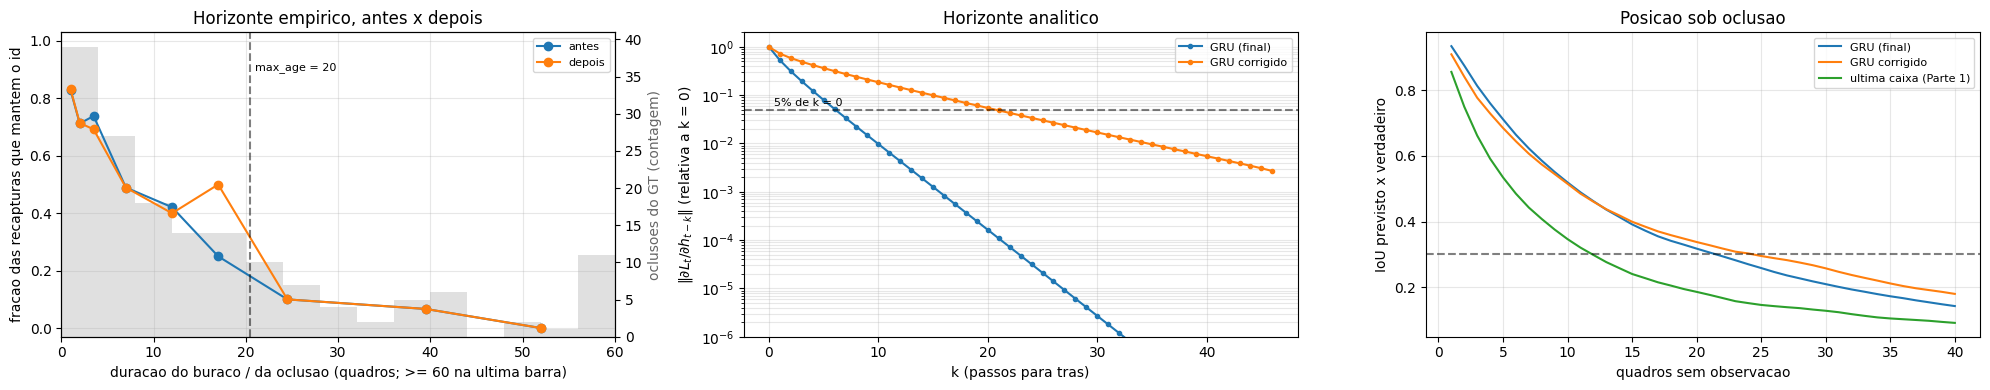

horizonte empirico (cruza 50%): antes 6.9, depois 6.8 quadros
antes: mantem o id em 43% das 82 recapturas apos buracos de 5-19 quadros
depois: mantem o id em 47% das 83 recapturas apos buracos de 5-19 quadros
horizonte analitico: antes 7, depois 21 passos
trecho MOT17-10 GT 31 (buraco 55): depois da correcao o id e mantido
trecho MOT17-10 GT 57 (buraco 19): depois da correcao o id e mantido


In [11]:
events_corr, preds_corr, all_corr = memory_profile(corrected[0])
rates_corr, hz_corr = rates_and_horizon(all_corr)
curves["GRU corrigido"] = gradient_curve(corrected[0], VAL)
fr["GRU corrigido"] = free_running_iou(corrected[0], VAL)

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
plot_memory_horizon({"antes": rates_final, "depois": rates_corr}, occ, max_age=TRACKER["max_age"], ax=axes[0],
                    title="Horizonte empirico, antes x depois")
plot_gradient_curves({k: curves[k] for k in ("GRU (final)", "GRU corrigido")}, ax=axes[1], title="Horizonte analitico")
for label in ("GRU (final)", "GRU corrigido", "ultima caixa (Parte 1)"):
    axes[2].plot(np.arange(1, len(fr[label]) + 1), fr[label], label=label)
axes[2].axhline(TRACKER["iou_threshold"], color="k", linestyle="--", alpha=0.5)
axes[2].set_xlabel("quadros sem observacao"); axes[2].set_ylabel("IoU previsto x verdadeiro")
axes[2].set_title("Posicao sob oclusao"); axes[2].grid(alpha=0.3); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"horizonte empirico (cruza 50%): antes {hz_final:.1f}, depois {hz_corr:.1f} quadros")
for name, evs in (("antes", all_final), ("depois", all_corr)):
    rate, n = keep_rate_between(evs, 5, 20)
    print(f"{name}: mantem o id em {rate:.0%} das {n} recapturas apos buracos de 5-19 quadros")
print(f"horizonte analitico: antes {effective_horizon(curves['GRU (final)'])}, depois {effective_horizon(curves['GRU corrigido'])} passos")
for d in diagnoses:
    if d["gap"] > 0:
        kept = [e for e in events_corr[d["seq"]] if e["gt_id"] == d["gt_id"] and e["frame"] == d["frame"]]
        print(f"trecho {d['seq']} GT {d['gt_id']} (buraco {d['gap']}): depois da correcao o id "
              f"{'e mantido' if kept and kept[0]['kept'] else 'continua trocado (ou a recaptura mudou de quadro)'}")

In [12]:

results = {
    "tracker": TRACKER,
    "detections": {"detector": "SDP", "min_score": 0.9},
    "model": DEFAULT_CONFIG | {"occlusion_len": list(DEFAULT_CONFIG["occlusion_len"])},
    "correction": LONG | {"occlusion_len": list(LONG["occlusion_len"])},
    "baseline_vs_final": comparison.reset_index().to_dict(orient="records"),
    "analytic_horizon": {k: effective_horizon(c) for k, c in curves.items()},
    "gradient_curves": {k: c.tolist() for k, c in curves.items()},
    "free_running_iou": {k: v.tolist() for k, v in fr.items()},
    "empirical_horizon": {"baseline": hz_base, "final": hz_final, "corrigido": hz_corr},
    "keep_rate": {"baseline": rates_base, "final": rates_final, "corrigido": rates_corr},
    "gt_occlusions": occ.tolist(),
    "failures": diagnoses,
    "correction_table": correction.reset_index().to_dict(orient="records"),
}
with open(os.path.join(RESULTS_DIR, "4_memory_horizon.json"), "w") as f:
    json.dump(results, f, indent=1, default=float)
print("salvo em", RESULTS_DIR)


salvo em results


## 5. Conclusões

### Modelo final

O GRU tem 14.468 parâmetros e usa só geometria. Ele melhora o baseline da Parte 1 nas duas sequências de validação:

| sequência | IDF1 baseline | IDF1 GRU (3 seeds) | IDSW baseline | IDSW GRU |
|---|---|---|---|---|
| MOT17-09 | 0,519 | 0,565 ± 0,007 | 66 | 41 |
| MOT17-10 | 0,501 | 0,530 ± 0,016 | 327 | 231 |

As fragmentações quase não mudam (127 → 128 no MOT17-09 e 460 → 455 no MOT17-10). No MOT17-09 o GRU cria um pouco mais de ids que o baseline (41 contra 35), mas troca menos. O ganho vem da caixa prevista. Sob oclusão, o IoU entre a caixa prevista pelo GRU e a verdadeira fica acima do limiar de associação (0,3) por 22 quadros, contra 12 da última caixa.

### Horizonte analítico

No GRU final, ‖∂L_t/∂h_{t−k}‖ cai 45 vezes em 8 passos e fica abaixo de 5 % em k = 7. A RNN simples com o mesmo orçamento (H = 114) chega ao mesmo horizonte, k = 7, com queda de 30 vezes em 8 passos. Depois disso a norma da RNN decai até mais devagar que a do GRU: em k = 20 ela vale 5,8·10⁻⁴ contra 1,6·10⁻⁴. A posição sob oclusão também é praticamente igual nas duas células, e a RNN cruza o limiar de IoU em 21 quadros contra 22 do GRU.

Com essa receita de treino, a porta não trouxe vantagem. Nada no treino pedia memória longa (janelas de 16 quadros e oclusões simuladas de até 8), e o que as duas células aprenderam é um extrapolador de velocidade de curto prazo. O gradiente que desaparece aparece aqui como um teto do que o treino supervisiona, e não como uma diferença entre células.

### Horizonte empírico

A fração de recapturas que mantém o id cruza 50 % em buracos de cerca de 7 quadros, tanto no baseline (6,8) quanto no GRU (6,9). A diferença está nas faixas intermediárias:

| buraco (quadros) | 1 | 2 | 3 a 4 | 5 a 9 | 10 a 14 | 15 a 19 | 20 a 29 | 30 a 49 | ≥ 50 |
|---|---|---|---|---|---|---|---|---|---|
| recapturas (GRU) | 299 | 87 | 65 | 47 | 19 | 16 | 20 | 15 | 15 |
| baseline | 0,82 | 0,62 | 0,65 | 0,49 | 0,20 | 0,24 | 0,11 | 0,00 | 0,00 |
| GRU | 0,83 | 0,71 | 0,74 | 0,49 | 0,42 | 0,25 | 0,10 | 0,07 | 0,00 |

Nos buracos de 5 a 19 quadros, o GRU mantém o id em 43 % das 82 recapturas, contra 37 % das 84 do baseline. Acima de 20 quadros quase nada sobrevive, porque `max_age = 20` mata a track. As faixas longas têm de 15 a 20 eventos cada, então as diferenças ali são pequenas demais para interpretar.

As oclusões do GT têm mediana de 10 quadros, p75 de 23 e p90 de 42. Delas, 62 % são mais longas que o horizonte empírico do GRU e 59 % são mais longas que o analítico. O modelo foi treinado e é usado para buracos menores que os que aparecem nos dados.

### Galeria

Os três trechos têm causas diferentes, detalhadas na seção 3. Na oclusão longa a track morre por `max_age`, e a previsão já tinha se afastado da pessoa parada. No buraco médio a track está viva, mas a previsão em linha reta não acompanha a mudança de direção (IoU 0 na volta). Na troca a previsão ainda tem IoU 0,56 com a pessoa certa, e o erro é da associação entre caixas sobrepostas, que só aparência resolveria. Os dois primeiros apontam para a mesma causa, a falta de supervisão através de buracos longos, e por isso são a base da correção.

### Correção

| variante | IDF1 MOT17-09 | IDF1 MOT17-10 | IDF1 médio | IDSW 09 | IDSW 10 |
|---|---|---|---|---|---|
| antes: T = 16, oclusão ≤ 8, `max_age = 20` | 0,565 ± 0,007 | 0,530 ± 0,016 | 0,547 | 41 | 231 |
| controle: só `max_age = 30` | 0,555 ± 0,018 | 0,523 ± 0,016 | 0,539 | 43 | 232 |
| depois: T = 32, oclusão de 8 a 24, `max_age = 20` | 0,603 ± 0,008 | 0,542 ± 0,022 | 0,573 | 38 | 264 |

O IDF1 médio sobe de 0,547 para 0,573. No MOT17-09 o ganho (0,565 → 0,603) é bem maior que o desvio entre seeds. No MOT17-10 (0,530 → 0,542) ele fica dentro do desvio. Os dois trechos da galeria com buraco (GT 31 e GT 57) passam a manter o id.

O horizonte analítico vai de 7 para 21 passos. A norma do gradiente decai muito mais devagar e ainda vale 2,7·10⁻³ em k = 46, contra 4·10⁻⁹ no modelo antigo. A taxa de manutenção nos buracos de 5 a 19 quadros sobe de 43 % (82 recapturas) para 47 % (83), quase toda pela faixa de 15 a 19 quadros, que vai de 0,25 para 0,50 com 16 eventos. O horizonte empírico de 50 % não muda (6,9 → 6,8 quadros), porque o ganho está em buracos que já ficavam abaixo de 50 %. A caixa prevista fica acima do limiar de associação por mais tempo (25 quadros contra 22), mas nos primeiros quadros sem observação o modelo corrigido é um pouco pior (IoU 0,909 contra 0,934 depois de 1 quadro e 0,685 contra 0,712 depois de 5).

O controle mostra que só aumentar `max_age` para 30 no modelo antigo não ajuda. O IDF1 médio fica em 0,539, dentro do desvio do modelo antigo, e os ID switches praticamente não mudam. O ganho vem do modelo e não da regra de morte.

O custo aparece no MOT17-10, que tem câmera móvel. Lá os ID switches sobem de 231 para 264 e as fragmentações de 455 para 461. O modelo corrigido confia mais na extrapolação, e com o movimento da câmera ela erra mais vezes, o que é coerente com a previsão um pouco pior nos primeiros quadros de oclusão. O diagnóstico fica confirmado em parte: o horizonte mais longo ajuda onde o movimento é do pedestre (MOT17-09), mas não substitui uma entrada que separe o movimento da câmera.

O modelo corrigido é o modelo final do teste de estresse da Parte 5 (`reports/5_stress_test.ipynb`).